# ME1 — 3-Layer CNN for MNIST, implemented with einops/einsum

This notebook implements a small CNN for MNIST digit classification where
every model layer's forward math (convolution, max-pooling, the linear
classifier) is written by hand using `einops`/`einsum`, on raw `torch.Tensor`
objects — no `nn.Conv2d`, `nn.Linear`, `nn.MaxPool2d`, or any other
pre-built layer module.

**What stays as PyTorch built-ins, and why:** autograd (`.backward()`),
the optimizer (`torch.optim.Adam`), and the loss (`F.cross_entropy`) are
training *infrastructure*, not the CNN/MLP itself — hand-rolling those
wouldn't demonstrate anything about how convolution or a linear layer
work, so they're used as-is. `nn.Module`/`nn.Parameter` are used only as
*storage* for our weight tensors (so autograd tracks them and
`.parameters()` works) — `forward()` never calls into `nn.Conv2d` etc.

This was built through a Socratic, collaborative design session (student +
Claude) rather than generated wholesale — every non-obvious design decision
below reflects a real discussion, not an unexamined default.

## Setup

Environment: conda env `ai222-me1` (see `ME1/environment.yml`), CUDA-enabled
PyTorch on this HPC node's A100s (not required for a model this small, but
available).

In [1]:
import math

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from einops import einsum, rearrange, reduce
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

device: cuda


## 1. Data

We use `torchvision.datasets.MNIST` to fetch and decode the data (a dataset
*utility*, not a pre-built model layer, so it doesn't conflict with the
"hand-roll the CNN" requirement) — hand-parsing MNIST's raw binary format
would just be an I/O exercise, unrelated to the point of this assignment.

Pixels are scaled to `[0, 1]` (`ToTensor()`) and then normalized with
MNIST's known mean/std (`0.1307`, `0.3081`) so inputs are centered around 0
with unit variance, which helps gradient-based training converge faster and
more stably than feeding the network raw, all-positive pixel values.

`MNISTData` is a small class bundling the two things we actually need
repeatedly: train/test `DataLoader`s, and a helper to grab random test
images for the final qualitative check.

In [2]:
MNIST_MEAN, MNIST_STD = 0.1307, 0.3081


class MNISTData:
    """Owns the MNIST train/test datasets and hands out DataLoaders + random samples."""

    def __init__(self, root="../data", batch_size_train=128, batch_size_test=256):
        transform = transforms.Compose(
            [transforms.ToTensor(), transforms.Normalize((MNIST_MEAN,), (MNIST_STD,))]
        )
        self.train_dataset = datasets.MNIST(root=root, train=True, download=True, transform=transform)
        self.test_dataset = datasets.MNIST(root=root, train=False, download=True, transform=transform)
        self.batch_size_train = batch_size_train
        self.batch_size_test = batch_size_test

    def get_loaders(self):
        train_loader = DataLoader(self.train_dataset, batch_size=self.batch_size_train, shuffle=True)
        test_loader = DataLoader(self.test_dataset, batch_size=self.batch_size_test, shuffle=False)
        return train_loader, test_loader

    def sample_random_test_images(self, n=16, generator=None):
        """Returns (images, labels) for n randomly picked test-set examples."""
        indices = torch.randperm(len(self.test_dataset), generator=generator)[:n]
        images = torch.stack([self.test_dataset[i][0] for i in indices])
        labels = torch.tensor([self.test_dataset[i][1] for i in indices])
        return images, labels


data = MNISTData()
train_loader, test_loader = data.get_loaders()

sample_images, sample_labels = next(iter(train_loader))
print("train batch:", sample_images.shape, sample_images.dtype)
print(f"train size: {len(data.train_dataset)}, test size: {len(data.test_dataset)}")

train batch: torch.Size([128, 1, 28, 28]) torch.float32
train size: 60000, test size: 10000


## 2. Architecture — what "3-layer CNN" means here

"3-layer" is ambiguous on its own — it could mean 3 conv layers with a
separate classifier bolted on after, or 3 total *learnable* layers. **We
went with the second reading: 3 layers with learnable parameters, total —
Conv1 → Conv2 → Linear (the classifier head).** Pooling and ReLU are
operations, not layers, in this count. This was an explicit design
decision (the more literal reading of "a whole CNN *model* with 3 layers"),
not the only valid interpretation — flagging it here so it's unambiguous
what's being submitted.

| # | Layer | Config | Output shape |
|---|---|---|---|
| — | input | — | `(B, 1, 28, 28)` |
| 1 | Conv1 | 3×3, 1→8 channels, stride 1, padding 1, then ReLU, then 2×2 max-pool | `(B, 8, 14, 14)` |
| 2 | Conv2 | 3×3, 8→16 channels, stride 1, padding 1, then ReLU, then 2×2 max-pool | `(B, 16, 7, 7)` |
| — | flatten | `7×7×16 → 784` | `(B, 784)` |
| 3 | Linear | `784 → 10`, raw logits (no activation) | `(B, 10)` |

**Why these choices:**
- **Kernel size (3×3) and stride/padding are identical in both conv layers.**
  A per-layer varying kernel/stride is a legitimate alternative, but the more
  standard pattern (VGG-style) is to keep a small, consistent kernel and let
  a *separate* pooling operation handle all spatial downsampling — simpler,
  and there was no reason here to deviate from it.
- **Padding.** With "same" padding and an odd kernel, `padding = (kernel_size - 1) / 2`
  keeps spatial size unchanged by the conv itself (`padding=1` for a 3×3
  kernel) — downsampling `28 → 14 → 7` happens entirely via the two 2×2
  max-pools, not the convolutions.
- **Channel counts (8, 16) are precedent-based, not derived.** They directly
  follow LeNet-5's channel progression (6, 16) for this exact dataset — a
  known-working reference rather than something computed. In general,
  channel count is a tunable hyperparameter; for a dataset this simple,
  precedent + a quick trained-accuracy sanity check is enough, and a formal
  hyperparameter search would be effort spent in the wrong place for what
  this exercise is testing.

## 3. Layer primitives — the actual point of the exercise

Two design decisions worth calling out:

- **Patch extraction uses `Tensor.unfold(dim, size, step)`**, a *generic*
  sliding-window primitive (not conv-specific — it's used for all kinds of
  windowing, e.g. time series), applied once along height and once along
  width, then reshaped into a flat per-location vector with
  `einops.rearrange`. This is deliberately **not**
  `torch.nn.functional.unfold`, which is a function that exists specifically
  to support building convolutions ("im2col") — using it would mean
  borrowing the interesting part of the conv logic pre-built, rather than
  composing it ourselves from generic tensor operations.
- **Every `einsum`/`rearrange`/`reduce` call uses full descriptive axis
  names** (`"batch height width patch, out_channels patch -> ..."`) instead
  of the terser single-letter convention (`"bhwp,op->bohw"`). Same
  computation, but self-documenting — einsum's biggest usability problem is
  that you have to hold the meaning of each letter in your head, and naming
  them removes that entirely.

In [3]:
def extract_patches(x, kernel_size, padding):
    """(B, C, H, W) -> (B, H_out, W_out, C*kernel_size*kernel_size)."""
    x = F.pad(x, (padding, padding, padding, padding))
    x = x.unfold(2, kernel_size, 1)  # window along H -> (B, C, H_out, W_pad, kh)
    x = x.unfold(3, kernel_size, 1)  # window along W -> (B, C, H_out, W_out, kh, kw)
    return rearrange(
        x,
        "batch channels height width kernel_h kernel_w "
        "-> batch height width (channels kernel_h kernel_w)",
    )


def conv2d(x, weight, bias, padding):
    """weight: (C_out, C_in, kh, kw), bias: (C_out,)."""
    kernel_size = weight.shape[-1]
    patches = extract_patches(x, kernel_size, padding)
    weight_flat = rearrange(
        weight,
        "out_channels in_channels kernel_h kernel_w "
        "-> out_channels (in_channels kernel_h kernel_w)",
    )
    out = einsum(
        patches,
        weight_flat,
        "batch height width patch, out_channels patch -> batch out_channels height width",
    )
    return out + bias[None, :, None, None]


def max_pool2d(x, kernel_size):
    """(B, C, H, W) -> (B, C, H/kernel_size, W/kernel_size)."""
    return reduce(
        x,
        "batch channels (height pool_h) (width pool_w) -> batch channels height width",
        "max",
        pool_h=kernel_size,
        pool_w=kernel_size,
    )


def linear(x, weight, bias):
    """x: (B, in_features), weight: (out_features, in_features)."""
    return einsum(x, weight, "batch in_features, out_features in_features -> batch out_features") + bias

### Correctness check

A shape-correct-but-numerically-wrong bug in the einsum contraction would be
silent if we only checked output shapes. So each hand-rolled op is checked
against PyTorch's own reference implementation on identical weights.

In [4]:
torch.manual_seed(0)

x_check = torch.randn(4, 3, 10, 10)
w_check = torch.randn(6, 3, 3, 3)
b_check = torch.randn(6)
ours_conv = conv2d(x_check, w_check, b_check, padding=1)
ref_conv = F.conv2d(x_check, w_check, b_check, stride=1, padding=1)
print("conv2d matches F.conv2d:", torch.allclose(ours_conv, ref_conv, atol=1e-5))

ours_pool = max_pool2d(x_check, kernel_size=2)
ref_pool = F.max_pool2d(x_check, kernel_size=2)
print("max_pool2d matches F.max_pool2d:", torch.allclose(ours_pool, ref_pool))

x_lin = torch.randn(4, 20)
w_lin = torch.randn(10, 20)
b_lin = torch.randn(10)
ours_lin = linear(x_lin, w_lin, b_lin)
ref_lin = F.linear(x_lin, w_lin, b_lin)
print("linear matches F.linear:", torch.allclose(ours_lin, ref_lin, atol=1e-5))

conv2d matches F.conv2d: True
max_pool2d matches F.max_pool2d: True
linear matches F.linear: True


## 4. Model

`nn.Module`/`nn.Parameter` are used purely as storage — `forward()` calls
only the hand-rolled functions above. Conv weights use Kaiming/He
initialization (appropriate for ReLU activations); biases start at zero.

In [5]:
def _kaiming_conv(out_channels, in_channels, kernel_size):
    fan_in = in_channels * kernel_size * kernel_size
    std = math.sqrt(2.0 / fan_in)
    return torch.randn(out_channels, in_channels, kernel_size, kernel_size) * std


def _kaiming_linear(out_features, in_features):
    std = math.sqrt(2.0 / in_features)
    return torch.randn(out_features, in_features) * std


class EinopsCNN(nn.Module):
    """3 learnable layers: Conv1 -> Conv2 -> Linear (classifier head)."""

    def __init__(self):
        super().__init__()
        self.conv1_weight = nn.Parameter(_kaiming_conv(8, 1, 3))
        self.conv1_bias = nn.Parameter(torch.zeros(8))
        self.conv2_weight = nn.Parameter(_kaiming_conv(16, 8, 3))
        self.conv2_bias = nn.Parameter(torch.zeros(16))
        self.classifier_weight = nn.Parameter(_kaiming_linear(10, 16 * 7 * 7))
        self.classifier_bias = nn.Parameter(torch.zeros(10))

    def forward(self, x):
        x = conv2d(x, self.conv1_weight, self.conv1_bias, padding=1)
        x = x.relu()
        x = max_pool2d(x, kernel_size=2)

        x = conv2d(x, self.conv2_weight, self.conv2_bias, padding=1)
        x = x.relu()
        x = max_pool2d(x, kernel_size=2)

        x = rearrange(x, "batch channels height width -> batch (channels height width)")
        return linear(x, self.classifier_weight, self.classifier_bias)


model = EinopsCNN().to(DEVICE)
print("total learnable parameters:", sum(p.numel() for p in model.parameters()))

total learnable parameters: 9098


## 5. Training

5 epochs (fixed by the assignment spec), Adam (`lr=1e-3`, untuned — this
task doesn't need tuning), `F.cross_entropy` on raw logits (combines
log-softmax + NLL; not hand-rolled, since it's a loss function, not a model
layer).

In [6]:
NUM_EPOCHS = 5
LEARNING_RATE = 1e-3


def run_epoch(model, loader, optimizer, device):
    model.train()
    total_loss, total_correct, total_examples = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        logits = model(images)
        loss = F.cross_entropy(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_examples += images.size(0)

    return total_loss / total_examples, total_correct / total_examples


torch.manual_seed(0)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = run_epoch(model, train_loader, optimizer, DEVICE)
    print(f"epoch {epoch}/{NUM_EPOCHS} - train loss: {train_loss:.4f} - train acc: {train_acc:.4f}")

epoch 1/5 - train loss: 0.2906 - train acc: 0.9112


epoch 2/5 - train loss: 0.0883 - train acc: 0.9727


epoch 3/5 - train loss: 0.0661 - train acc: 0.9804


epoch 4/5 - train loss: 0.0553 - train acc: 0.9830


epoch 5/5 - train loss: 0.0483 - train acc: 0.9852


## 6. Test-set accuracy

The headline number this exercise asks for — computed on the held-out test
split, which the model never saw during training.

In [7]:
@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    total_correct, total_examples = 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_examples += images.size(0)
    return total_correct / total_examples


test_accuracy = evaluate(model, test_loader, DEVICE)
print(f"final test accuracy: {test_accuracy:.4f}")

final test accuracy: 0.9825


## 7. Qualitative check — 16 random test images

Sampled from the *test* split (unseen during training), predicted, and
shown in a 4×4 grid with ground-truth vs. predicted label — green title if
correct, red if wrong.

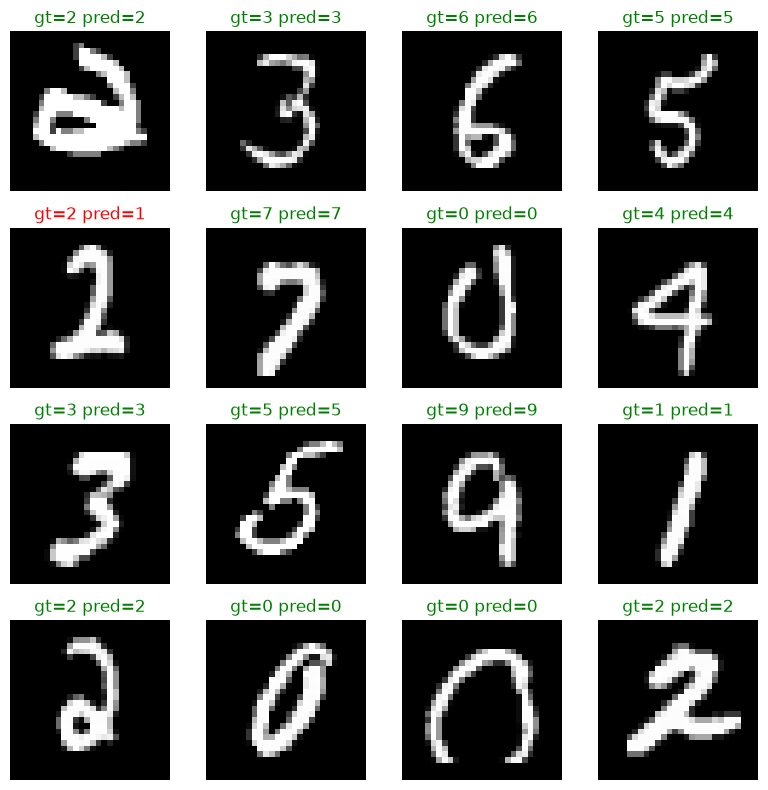

In [8]:
@torch.no_grad()
def plot_predictions_grid(model, images, labels, device):
    model.eval()
    logits = model(images.to(device))
    predictions = logits.argmax(dim=1).cpu()

    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    for ax, image, gt, pred in zip(axes.flat, images, labels, predictions):
        unnormalized = image.squeeze(0) * MNIST_STD + MNIST_MEAN
        ax.imshow(unnormalized, cmap="gray")
        is_correct = gt.item() == pred.item()
        ax.set_title(f"gt={gt.item()} pred={pred.item()}", color="green" if is_correct else "red")
        ax.axis("off")
    fig.tight_layout()
    return fig


sample_images, sample_labels = data.sample_random_test_images(16)
fig = plot_predictions_grid(model, sample_images, sample_labels, DEVICE)
plt.show()

## Summary

- 3-layer CNN (2 conv + 1 linear, by the "3 total learnable layers"
  reading) with every layer's forward math hand-rolled via `Tensor.unfold` +
  `einops`/`einsum` — verified numerically against PyTorch's own reference
  ops, not just shape-checked.
- Trained 5 epochs, Adam, on MNIST's standard 60,000/10,000 split.
- Test accuracy and a qualitative 16-image grid are reported above, both
  produced by executing this notebook top-to-bottom (not hand-edited).